In [1]:
%pip install "medprep-starter[medical] @ git+https://github.com/Z-bros/Med_Im_Prepper.git"
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import medprep

from medprep import (
    MedicalPipeline,
    PreprocessConfig,
    AugmentConfig,
)

print("medprep version:", medprep.__version__)

  Cloning https://github.com/Z-bros/Med_Im_Prepper.git to /tmp/pip-install-rdrbn6sm/medprep-starter_9405823da6b44c61a7923b8d4e0e5cb1
  Running command git clone --filter=blob:none --quiet https://github.com/Z-bros/Med_Im_Prepper.git /tmp/pip-install-rdrbn6sm/medprep-starter_9405823da6b44c61a7923b8d4e0e5cb1
  Resolved https://github.com/Z-bros/Med_Im_Prepper.git to commit 9fff4d7cc4e55190a63e1d94190a90b3ceded8aa
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Created wheel for medprep-starter: filename=medprep_starter-0.2.0-py3-none-any.whl size=15503 sha256=c632824338b4b493d8ebef0148e01fde317704515f0159823342e28889df3216
  Stored in directory: /tmp/pip-ephem-wheel-cache-y1k3m2fo/wheels/de/f5/8a/e994093450acec394d6073104c38f80d0b53cbec90fc216d93
Successfully built medprep-starter
Note: you may need to restart the kernel to use updated packages.
medprep version: 0.2.0


# Load the volume_resized from previous notebook

In [2]:
volume_path = Path("/kaggle/input/datasets/zidanefatuna/volume-resized/volume_resized.npy")

volume_resized = np.load(volume_path, allow_pickle=False)

print("Shape:", volume_resized.shape)
print("Data type:", volume_resized.dtype)

Shape: (22, 224, 224)
Data type: float32


# Image Rotation for Augmentation 

In [3]:
rotation_pipeline = MedicalPipeline(
    preprocessing=PreprocessConfig(
        spatial_dims=3,
        normalization="none",
    ),
    augmentation=AugmentConfig(
        rotation_degrees=7,
        rotation_axes=(1, 2),
        rotation_probability=1.0,
    ),
    seed=42,
)

rotation_result = rotation_pipeline(
    volume_resized,
    training=True,
)

volume_rotated = rotation_result["image"]

print(rotation_result["metadata"]["augmentation"])

[{'rotation_degrees': -0.8557018434712678, 'axes': (1, 2)}]


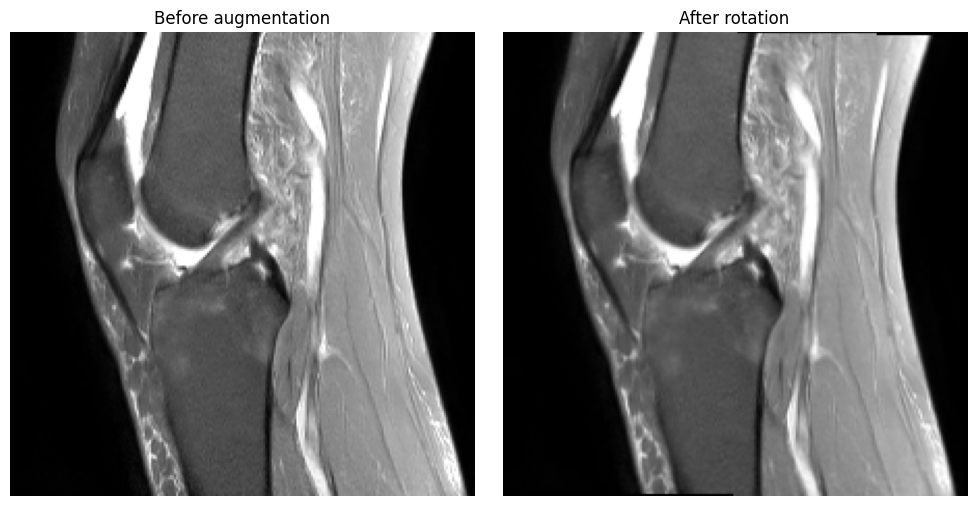

In [4]:
slice_index = len(volume_resized) // 2

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for ax, data, title in zip(
    axes,
    [volume_resized, volume_rotated],
    ["Before augmentation", "After rotation"],
):
    ax.imshow(
        data[slice_index],
        cmap="gray",
        vmin=0,
        vmax=1,
    )
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

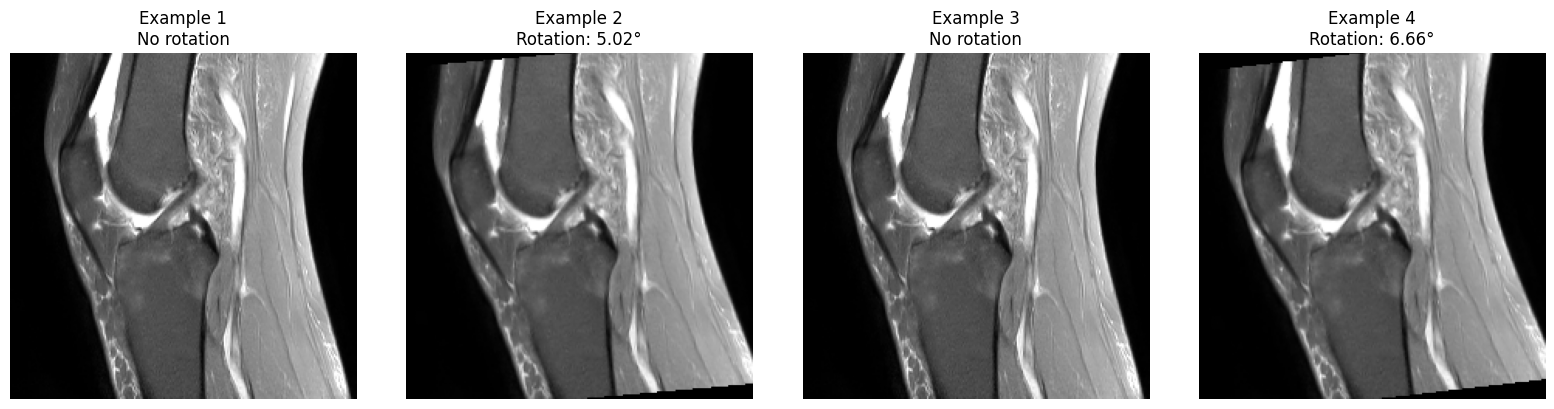

In [5]:
augmentation_pipeline = MedicalPipeline(
    preprocessing=PreprocessConfig(
        spatial_dims=3,
        normalization="none",
    ),
    augmentation=AugmentConfig(
        rotation_degrees=7,
        rotation_axes=(1, 2),
        rotation_probability=0.5,
    ),
    seed=42,
)

slice_index = len(volume_resized) // 2
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for i, ax in enumerate(axes):
    result = augmentation_pipeline(
        volume_resized,
        training=True,
    )

    history = result["metadata"]["augmentation"]
    angle = next(
        (op["rotation_degrees"] for op in history
         if "rotation_degrees" in op),
        None,
    )

    title = (
        "No rotation"
        if angle is None
        else f"Rotation: {angle:.2f}°"
    )

    ax.imshow(
        result["image"][slice_index],
        cmap="gray",
        vmin=0,
        vmax=1,
    )
    ax.set_title(f"Example {i + 1}\n{title}")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [6]:
validation_result = augmentation_pipeline(
    volume_resized,
    training=False,
)

print(
    "Validation image unchanged:",
    np.array_equal(
        validation_result["image"],
        volume_resized,
    ),
)
print(
    "Validation augmentation:",
    validation_result["metadata"]["augmentation"],
)

Validation image unchanged: True
Validation augmentation: []


# Checking for reproducibility

In [7]:
augmentation_pipeline.reseed(42)
first = augmentation_pipeline(volume_resized, training=True)

augmentation_pipeline.reseed(42)
second = augmentation_pipeline(volume_resized, training=True)

print(
    "Same output after resetting seed:",
    np.array_equal(first["image"], second["image"]),
)
print("First augmentation:", first["metadata"]["augmentation"])
print("Second augmentation:", second["metadata"]["augmentation"])

Same output after resetting seed: True
First augmentation: []
Second augmentation: []


In [8]:
rotation_pipeline.reseed(42)
first = rotation_pipeline(volume_resized, training=True)

rotation_pipeline.reseed(42)
second = rotation_pipeline(volume_resized, training=True)

print(
    "Same rotated output:",
    np.array_equal(first["image"], second["image"]),
)
print("First augmentation:", first["metadata"]["augmentation"])
print("Second augmentation:", second["metadata"]["augmentation"])

Same rotated output: True
First augmentation: [{'rotation_degrees': -0.8557018434712678, 'axes': (1, 2)}]
Second augmentation: [{'rotation_degrees': -0.8557018434712678, 'axes': (1, 2)}]


# Image Noise for Augmentation 

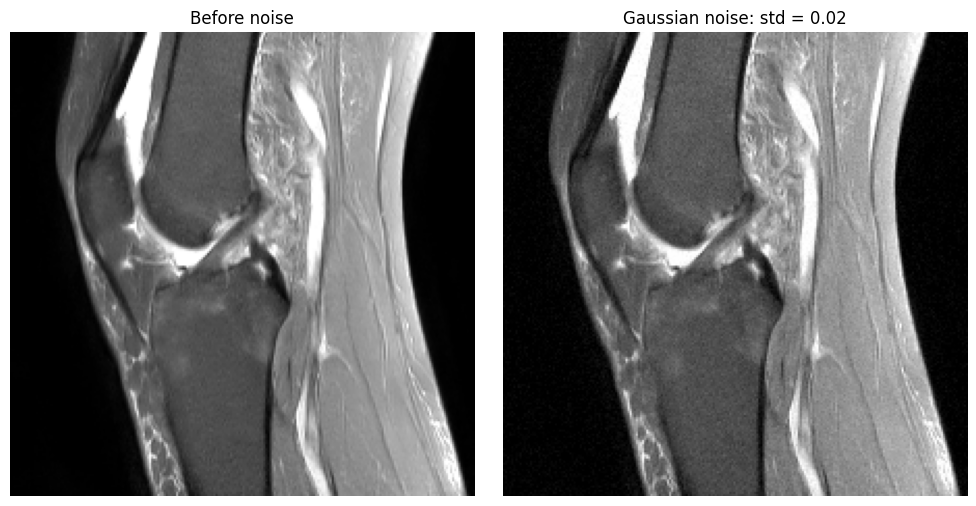

Original range: 0.0 1.0
Noisy range: -0.09000994 1.0982251


In [9]:
noise_pipeline = MedicalPipeline(
    preprocessing=PreprocessConfig(
        spatial_dims=3,
        normalization="none",
    ),
    augmentation=AugmentConfig(
        noise_std=0.02,
        noise_probability=1.0,
    ),
    seed=42,
)

noise_result = noise_pipeline(volume_resized, training=True)
volume_noisy = noise_result["image"]

slice_index = len(volume_resized) // 2

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for ax, data, title in zip(
    axes,
    [volume_resized, volume_noisy],
    ["Before noise", "Gaussian noise: std = 0.02"],
):
    ax.imshow(
        data[slice_index],
        cmap="gray",
        vmin=0,
        vmax=1,
    )
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

print("Original range:", volume_resized.min(), volume_resized.max())
print("Noisy range:", volume_noisy.min(), volume_noisy.max())

# Image Translation for Augmentation

[{'translation_pixels': [0.0, 3.585979199113824, 1.9736802905936388]}]


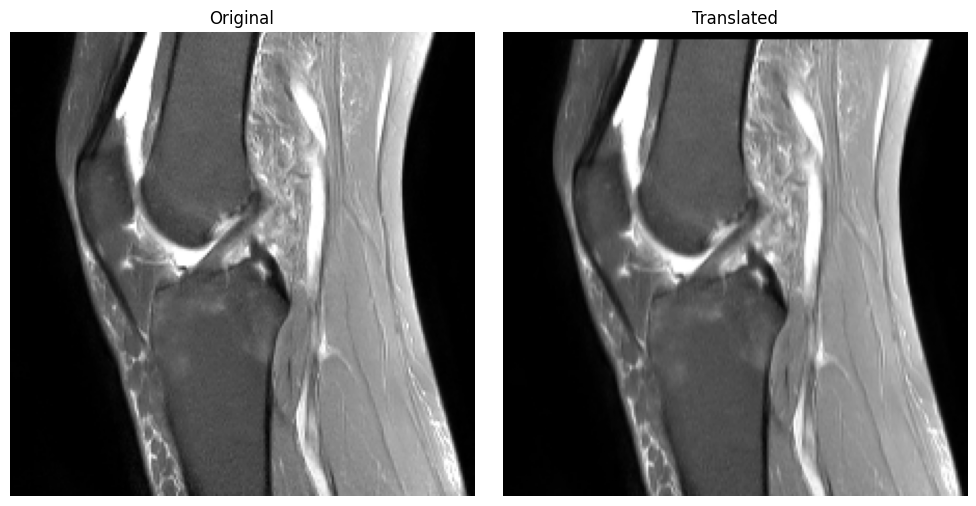

In [10]:
translation_pipeline = MedicalPipeline(
    preprocessing=PreprocessConfig(spatial_dims=3),
    augmentation=AugmentConfig(
        translation_pixels=(0, 5, 5),
        translation_probability=1.0,
    ),
    seed=42,
)

translated = translation_pipeline(
    volume_resized,
    training=True,
)

print(translated["metadata"]["augmentation"])

slice_index = len(volume_resized) // 2
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for ax, data, title in zip(
    axes,
    [volume_resized, translated["image"]],
    ["Original", "Translated"],
):
    ax.imshow(data[slice_index], cmap="gray", vmin=0, vmax=1)
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

# Image Zooming for Augmentation

[{'zoom_factor': 1.1, 'axes': [1, 2]}]
Output shape: (22, 224, 224)


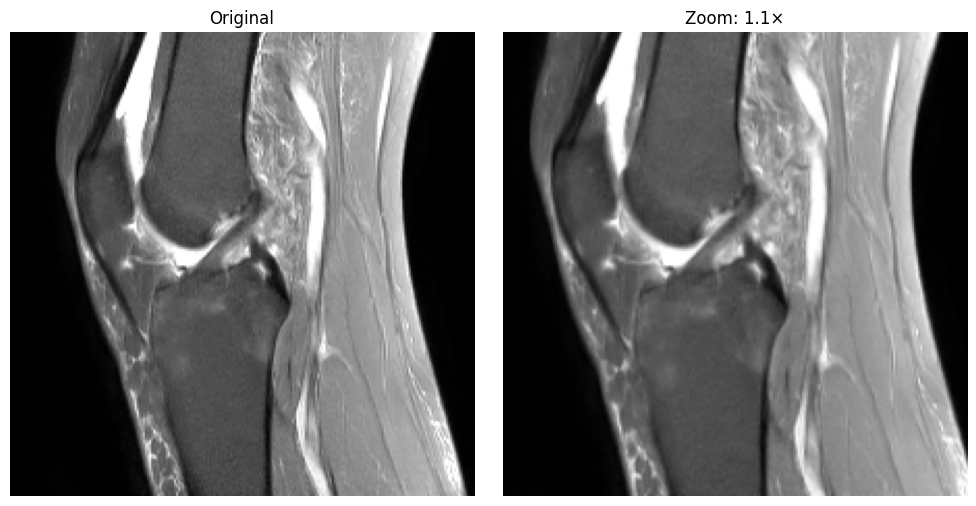

In [11]:
zoom_pipeline = MedicalPipeline(
    preprocessing=PreprocessConfig(spatial_dims=3),
    augmentation=AugmentConfig(
        zoom_range=(1.1, 1.1),
        zoom_axes=(1, 2),
        zoom_probability=1.0,
    ),
    seed=42,
)

zoomed = zoom_pipeline(volume_resized, training=True)

print(zoomed["metadata"]["augmentation"])
print("Output shape:", zoomed["image"].shape)

slice_index = len(volume_resized) // 2
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for ax, data, title in zip(
    axes,
    [volume_resized, zoomed["image"]],
    ["Original", "Zoom: 1.1×"],
):
    ax.imshow(data[slice_index], cmap="gray", vmin=0, vmax=1)
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

# Image Intensity for Augmentation

[{'intensity_scale': 1.1, 'intensity_shift': 0.02}]
Output range: 0.02 1.12


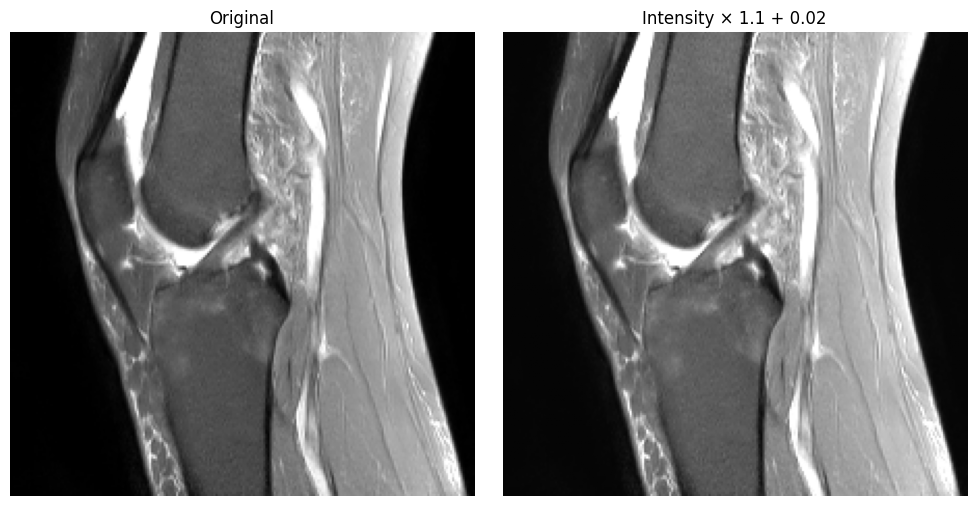

In [12]:
intensity_pipeline = MedicalPipeline(
    preprocessing=PreprocessConfig(spatial_dims=3),
    augmentation=AugmentConfig(
        intensity_scale_range=(1.1, 1.1),
        intensity_shift_range=(0.02, 0.02),
        intensity_probability=1.0,
    ),
    seed=42,
)

adjusted = intensity_pipeline(volume_resized, training=True)

print(adjusted["metadata"]["augmentation"])
print("Output range:",
      adjusted["image"].min(), adjusted["image"].max())

slice_index = len(volume_resized) // 2
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for ax, data, title in zip(
    axes,
    [volume_resized, adjusted["image"]],
    ["Original", "Intensity × 1.1 + 0.02"],
):
    ax.imshow(data[slice_index], cmap="gray", vmin=0, vmax=1)
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

# Image Blur for Augmentation

[{'blur_sigma_pixels': [0.0, 0.8, 0.8]}]


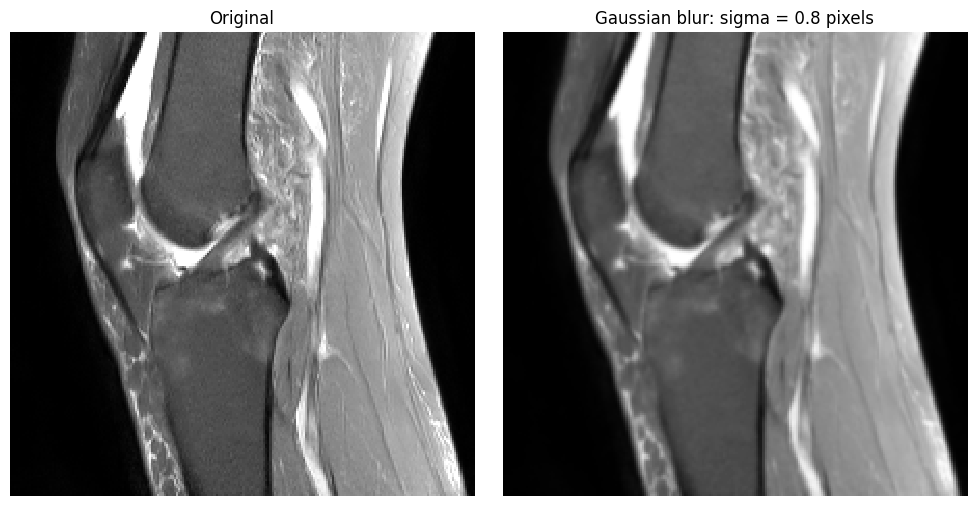

In [13]:
blur_pipeline = MedicalPipeline(
    preprocessing=PreprocessConfig(spatial_dims=3),
    augmentation=AugmentConfig(
        blur_sigma_range=(0.8, 0.8),
        blur_axes=(1, 2),
        blur_probability=1.0,
    ),
    seed=42,
)

blurred = blur_pipeline(volume_resized, training=True)

print(blurred["metadata"]["augmentation"])

slice_index = len(volume_resized) // 2
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for ax, data, title in zip(
    axes,
    [volume_resized, blurred["image"]],
    ["Original", "Gaussian blur: sigma = 0.8 pixels"],
):
    ax.imshow(
        data[slice_index],
        cmap="gray",
        vmin=0,
        vmax=1,
        interpolation="nearest",
    )
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

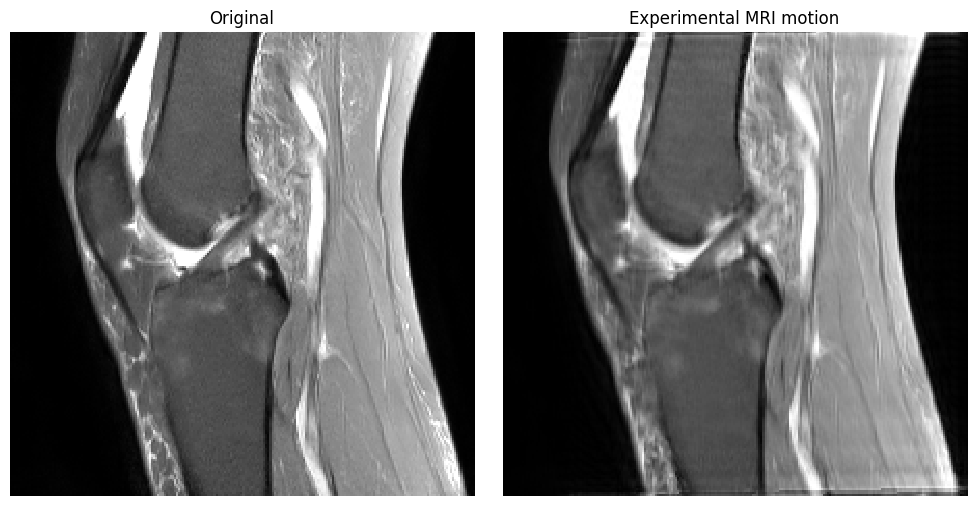

In [14]:
motion_pipeline = MedicalPipeline(
    preprocessing=PreprocessConfig(spatial_dims=3),
    augmentation=AugmentConfig(
        motion_degrees=3,
        motion_translation_pixels=(2, 2),
        motion_axes=(1, 2),
        motion_phase_axis=1,
        motion_segments=3,
        motion_probability=1.0,
    ),
    seed=42,
)

motion_result = motion_pipeline(volume_resized, training=True)

slice_index = len(volume_resized) // 2
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for ax, data, title in zip(
    axes,
    [volume_resized, motion_result["image"]],
    ["Original", "Experimental MRI motion"],
):
    ax.imshow(
        data[slice_index],
        cmap="gray",
        vmin=0,
        vmax=1,
        interpolation="nearest",
    )
    ax.set_title(title)
    ax.axis("off")

plt.tight_layout()
plt.show()

# Combined augmentation for training, excluding the motion artifacts

In [15]:
combined_pipeline = MedicalPipeline(
    preprocessing=PreprocessConfig(
        spatial_dims=3,
        normalization="none",
    ),
    augmentation=AugmentConfig(
        rotation_degrees=7,
        rotation_axes=(1, 2),
        rotation_probability=0.5,

        translation_pixels=(0, 5, 5),
        translation_probability=0.5,

        zoom_range=(0.95, 1.05),
        zoom_axes=(1, 2),
        zoom_probability=0.5,

        intensity_scale_range=(0.9, 1.1),
        intensity_shift_range=(-0.02, 0.02),
        intensity_probability=0.5,

        blur_sigma_range=(0.3, 0.8),
        blur_axes=(1, 2),
        blur_probability=0.2,

        noise_std=0.02,
        noise_probability=0.3,
    ),
    seed=42,
)

Variation 1:
  {'translation_pixels': [0.0, 1.9736802905936388, -4.058226521123505]}
  {'noise_std': 0.02}
Variation 2:
  {'translation_pixels': [0.0, 2.029704316829979, -3.9792208609404565]}
  {'zoom_factor': 1.046689058292335, 'axes': [1, 2]}
  {'noise_std': 0.02}
Variation 3:
  {'translation_pixels': [0.0, 1.53160008441019, 2.6617897616606996]}
  {'zoom_factor': 1.0479369711382924, 'axes': [1, 2]}
  {'blur_sigma_pixels': [0.0, 0.5381086638345434, 0.5381086638345434]}


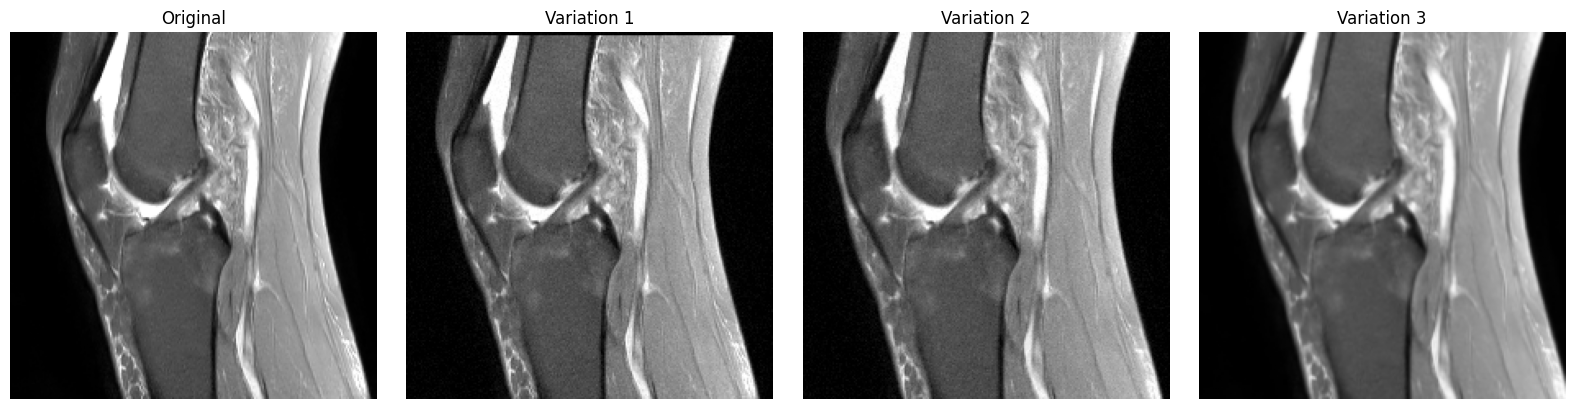

In [16]:
slice_index = len(volume_resized) // 2
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(
    volume_resized[slice_index],
    cmap="gray", vmin=0, vmax=1,
)
axes[0].set_title("Original")
axes[0].axis("off")

for i, ax in enumerate(axes[1:], start=1):
    result = combined_pipeline(volume_resized, training=True)

    ax.imshow(
        result["image"][slice_index],
        cmap="gray", vmin=0, vmax=1,
    )
    ax.set_title(f"Variation {i}")
    ax.axis("off")

    print(f"Variation {i}:")
    for operation in result["metadata"]["augmentation"]:
        print(" ", operation)

plt.tight_layout()
plt.show()

In [17]:
validation_result = combined_pipeline(
    volume_resized,
    training=False,
)

# The Take

- Augmentation was explored on one preprocessed sagittal series with shape
  `(22, 224, 224)`. These observations do not establish suitability across
  the full dataset.
- Rotation, translation, and zoom applied shared geometric parameters
  across all slices. They can introduce empty borders or crop anatomy.
- Intensity adjustment changed brightness and intensity differences.
  Gaussian noise added graininess, while Gaussian blur smoothed detail.
- Intensity adjustment and noise can produce values outside `[0, 1]`.
  Display limits do not clip the underlying arrays.
- Experimental MRI motion produced visible artifacts through simplified
  k-space mixing. It was excluded from the combined pipeline because its
  realism for these scans has not been established.
- The combined pipeline sampled rotation, translation, zoom, intensity
  adjustment, blur, and noise independently using specified probabilities.
  Each variation started from the original preprocessed volume.
- `training=False` disabled augmentation. Resetting the random seed
  reproduced the same transformations and outputs.
- Augmentation settings remain experimental. Their value must be assessed
  against a no-augmentation baseline using the same held-out studies.
- Augmented copies do not constitute new independent patients. All slices,
  series, and augmented versions of a study must remain in the same split;
  studies from the same patient must also stay together where identifiable.